# LLM Airline Assistant: агент с инструментами (Tool-based Agent)

В этой части проекта реализован LLM-агент с поддержкой инструментов. 

Агент умеет определять, когда необходимо использовать внешний API, и вызывает соответствующие функции для выполнения пользовательских запросов.

In [ ]:
from openai import OpenAI
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
MODEL = "gpt-4o-mini"

client = OpenAI()

def call_llm(prompt: str) -> str:
    response = client.responses.create(
        model=MODEL,
        input=prompt,
    )

    return response.output_text

In [ ]:
from typing import List, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, END


SYSTEM_PROMPT = """
  You are a virtual airline assistant.
  IMPORTANT: In this lesson you have NO tools, NO database access, NO RAG.
  You must be transparent about limitations:
  - You cannot look up flights, reservations, user profiles, baggage on a specific reservation, insurance status, or real-time flight status.
  - You can only: explain the policy, ask clarifying questions, and outline what info is needed to proceed.
  - Do NOT invent flight details, reservation details, membership level, prices, or statuses.
  - Do NOT provide subjective recommendations.
"""

llm = ChatOpenAI(model=MODEL)

class AgentState(TypedDict):
    messages: List[BaseMessage]


def llm_node(state: AgentState) -> AgentState:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}


graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)

app = graph.compile()

def ask(user_text: str, app) -> str:
    print("\n🟣 USER QUERY")
    print(">" * 50)
    print(user_text)

    state = {"messages": [HumanMessage(content=user_text)]}
    out = app.invoke(state)
    answer = out["messages"][-1].content

    print("\n🟢 AGENT RESPONSE")
    print("<" * 50)
    print(answer)
    print()


ask('Who are you?', app)


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Who are you?

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
I am a virtual airline assistant here to help you with airline-related questions and policies. I can explain airline policies, answer questions about general procedures, and outline the information needed to assist you further. However, I cannot access specific flight details, reservations, or real-time updates. How can I assist you today?



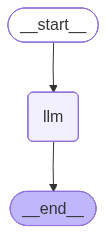

In [ ]:
app

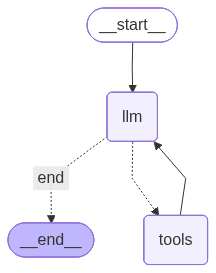

In [ ]:
import json
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

DATABASE = {
    "flights": {
        "AY001_2026-02-22": {
            "flight_key": "AY001_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "09:30",
            "seats": 3,
            "price": 120,
        },
        "AY101_2026-02-22": {
            "flight_key": "AY101_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "16:10",
            "seats": 1,
            "price": 155,
        },
    },
    "bookings": {
        "BKG-123": {
            "booking_id": "BKG-123",
            "flight_key": "AY001_2026-02-22",
            "passenger_name": "Jane Doe",
            "status": "confirmed",
        }
    },
}


# -----------------------
# 1) Tools
# -----------------------
@tool
def get_booking(booking_id: str) -> str:
    """Retrieve a booking by ID."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": f"Booking {booking_id} not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"], {})
    return json.dumps(
        {"booking_id": booking_id, **booking_record, "flight": flight_record},
        ensure_ascii=False,
    )


@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search available flights."""
    matching_flights = [
        flight
        for flight in DATABASE["flights"].values()
        if flight["from"] == origin
        and flight["to"] == destination
        and flight["date"] == date
        and flight["seats"] > 0
    ]
    return json.dumps(
        sorted(matching_flights, key=lambda f: f["time"]),
        ensure_ascii=False,
    )


@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel a booking."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": "Booking not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"])
    booking_record["status"] = "cancelled"

    if flight_record:
        flight_record["seats"] += 1

    refund_amount = flight_record["price"] if flight_record else 0
    return json.dumps({"success": True, "refund": refund_amount}, ensure_ascii=False)


TOOLS = [get_booking, search_flights, cancel_booking]


# -----------------------
# 2) Prompt (system)
# -----------------------
POLICIES: List[str] = [
    "Use tools when they are needed to answer accurately",
    "Never invent booking details, flight details, prices, or statuses",
    "If information is insufficient, ask clarifying questions.",
    "Request confirmation before any booking cancellation. Ask explicitly and wait for user confirmation",
    "Retrieve the current booking before proposing changes",
]

SYSTEM_PROMPT = ("You are a virtual airline assistant." + f"\nPOLICIES: {chr(10).join(f"* {p}" for p in POLICIES)}").strip()


class AgentStateRed(TypedDict):
    # messages: List[BaseMessage]
    messages: Annotated[List[BaseMessage], add_messages]


# -----------------------
# 3) LLM node
# -----------------------
# llm = ChatOpenAI(model=MODEL)
llm_with_tools = ChatOpenAI(model=MODEL).bind_tools(TOOLS)


def llm_with_tools_node(state: AgentStateRed) -> AgentStateRed:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm_with_tools.invoke(msgs)
    return {"messages": [resp]}


# ----------------------------
# 4) Router
# ----------------------------
def route_after_llm(state: AgentStateRed) -> Literal["tools", "end"]:
    last = state["messages"][-1]
    has_tool_calls = getattr(last, "tool_calls", None)
    return "tools" if has_tool_calls else "end"


graph_with_tools = StateGraph(AgentStateRed)

graph_with_tools.add_node("llm", llm_with_tools_node)
graph_with_tools.add_node("tools", ToolNode(TOOLS))

graph_with_tools.set_entry_point("llm")

graph_with_tools.add_conditional_edges(
    "llm",
    route_after_llm,
    {"tools": "tools", "end": END},
)

graph_with_tools.add_edge("tools", "llm")

app_with_tools = graph_with_tools.compile()

app_with_tools

In [ ]:
ask("Find flights from HEL to AMS on 2026-02-22", app_with_tools)
ask("What's in booking BKG-123?", app_with_tools)
ask("Cancel booking BKG-123", app_with_tools) 



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Find flights from HEL to AMS on 2026-02-22

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Here are the available flights from HEL to AMS on February 22, 2026:

1. **Flight AY001**
   - **Departure:** 09:30
   - **Seats Available:** 3
   - **Price:** €120

2. **Flight AY101**
   - **Departure:** 16:10
   - **Seats Available:** 1
   - **Price:** €155

If you would like to book a flight or need more information, please let me know!


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
What's in booking BKG-123?

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
The details of booking BKG-123 are as follows:

- **Passenger Name:** Jane Doe
- **Status:** Confirmed
- **Flight:** AY001
- **From:** Helsinki (HEL)
- **To:** Amsterdam (AMS)
- **Date:** February 22, 2026
- **Time:** 09:30
- **Seats:** 3
- **Price:** $120

If you need any further assistance or changes to this bookin

In [ ]:
class Chat:
    def __init__(self, app):
        self.state = {"messages": []}
        self.app = app

    def ask(self, user_text: str) -> str:
        print("\n🟣 USER QUERY")
        print(">" * 50)
        print(user_text)

        self.state["messages"].append(HumanMessage(content=user_text))
        out = self.app.invoke(self.state)
        self.state = out
        answer = out["messages"][-1].content


        print("\n🟢 AGENT RESPONSE")
        print("<" * 50)
        print(answer)
        print()


chat = Chat(app_with_tools)
print(chat.ask("Cancel booking BKG-123"))



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Cancel booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Your booking under the ID **BKG-123** is confirmed for the following flight details:

- **Passenger Name:** Jane Doe
- **Flight:** AY001
- **From:** Helsinki (HEL)
- **To:** Amsterdam (AMS)
- **Date:** February 22, 2026
- **Time:** 09:30
- **Seats:** 3
- **Price:** $120

Before I proceed with the cancellation of this booking, could you please confirm that you would like to cancel this booking?

None


In [ ]:
chat.ask("I confirm the cancellation of booking BKG-123")


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
I confirm the cancellation of booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Your booking **BKG-123** has been successfully canceled. A refund of **$120** will be processed back to your account. 

If you need any further assistance or have any questions, feel free to ask!



### Выводы

- Качество зависит от корректности описания инструментов
- LLM успешно выбирает инструменты при наличии явных инструкций